#  EDA: Анализ рынка недвижимости России 2021

**Датасет:** Russia Real Estate 2021 (Kaggle) — 11.3 млн объявлений  
**Цель:** найти закономерности в ценах на жильё по регионам, типам объектов и времени  
**Инструменты:** pandas, matplotlib, seaborn  

---

### План работы
1. Загрузка и первый взгляд на данные
2. Чистка — пропуски, дубликаты, аномалии
3. Создание новых признаков
4. Анализ цен и распределений
5. Динамика рынка по месяцам
6. Взаимосвязи признаков
7. Выводы

## 1. Загрузка данных

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('input_data.csv', sep=';')

print(df.shape)
print(df.dtypes)
df.head()

(11358150, 15)
date                 str
price              int64
level              int64
levels             int64
rooms              int64
area             float64
kitchen_area     float64
geo_lat          float64
geo_lon          float64
building_type      int64
object_type        int64
postal_code      float64
street_id        float64
id_region          int64
house_id         float64
dtype: object


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0


In [5]:

print("Пропуски:")
print(df.isnull().sum())
print()
print(f"Дубликаты: {df.duplicated().sum()}")
print()
print(df[['price', 'area', 'kitchen_area', 'rooms', 'level', 'levels']].describe())

Пропуски:
date                   0
price                  0
level                  0
levels                 0
rooms                  0
area                   0
kitchen_area           0
geo_lat                0
geo_lon                0
building_type          0
object_type            0
postal_code       507771
street_id        4205554
id_region              0
house_id         3261943
dtype: int64

Дубликаты: 396685

              price          area  kitchen_area         rooms         level  \
count  1.135815e+07  1.135815e+07  1.135815e+07  1.135815e+07  1.135815e+07   
mean   6.787516e+06  5.310356e+01 -2.674071e+00  1.719417e+00  6.426675e+00   
std    1.977118e+08  2.712845e+01  3.241855e+01  1.157606e+00  5.283144e+00   
min    0.000000e+00  1.000000e+00 -1.000000e+02 -1.000000e+00  0.000000e+00   
25%    2.600000e+06  3.650000e+01  0.000000e+00  1.000000e+00  2.000000e+00   
50%    3.995000e+06  4.670000e+01  6.500000e+00  2.000000e+00  5.000000e+00   
75%    6.500000e+06  6.300000

## 2. Чистка данных
Проверяем пропуски, дубликаты и аномальные значения.
Удаляем технические колонки (street_id, house_id, postal_code) — в них слишком много пропусков.
Фильтруем выбросы по цене (100k–100млн руб) и площади (10–500 м²).

In [6]:

df = df.drop_duplicates()
print(f"После удаления дубликатов: {df.shape}")


df = df.drop(columns=['street_id', 'house_id', 'postal_code'])


df = df[df['price'] > 100_000]        
df = df[df['price'] < 100_000_000]     
df = df[df['area'] > 10]               
df = df[df['area'] < 500]             
df = df[df['kitchen_area'] >= 0]      
df = df[df['rooms'] > 0]               
df = df[df['rooms'] <= 10]             
df = df[df['level'] > 0]                
df = df[df['level'] <= df['levels']]     

df['date'] = pd.to_datetime(df['date'])

print(f"Итого строк после чистки: {df.shape[0]}")
print(df.isnull().sum())

После удаления дубликатов: (10961465, 15)
Итого строк после чистки: 9214824
date             0
price            0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
geo_lat          0
geo_lon          0
building_type    0
object_type      0
id_region        0
dtype: int64


## 3. Создание новых признаков
Добавляем цену за м² как главную метрику сравнения,
категорию этажа и читаемое название типа объекта.

In [7]:

df['price_per_m2'] = df['price'] / df['area']


def floor_category(row):
    if row['level'] == 1:
        return 'первый'
    elif row['level'] == row['levels']:
        return 'последний'
    else:
        return 'средний'

df['floor_category'] = df.apply(floor_category, axis=1)


df['object_type_name'] = df['object_type'].map({0: 'вторичка', 2: 'новостройка'})


df['month'] = df['date'].dt.to_period('M')

print(df[['price', 'area', 'price_per_m2', 'floor_category', 'object_type_name']].head(10))
print()
print("Типы объектов:")
print(df['object_type_name'].value_counts())
print()
print("Уникальных регионов:", df['id_region'].nunique())

      price   area   price_per_m2 floor_category object_type_name
0   2451300   30.3   80900.990099        средний      новостройка
1   1450000   33.0   43939.393939      последний         вторичка
2  10700000   85.0  125882.352941        средний         вторичка
3   3100000   82.0   37804.878049        средний         вторичка
4   2500000   30.0   83333.333333        средний      новостройка
5   1450000   47.0   30851.063830      последний         вторичка
6   9000000  107.4   83798.882682        средний         вторичка
7   2990000   54.0   55370.370370         первый         вторичка
8   2300000   39.7   57934.508816        средний         вторичка
9   2290000   53.2   43045.112782      последний         вторичка

Типы объектов:
object_type_name
вторичка       6991121
новостройка    2223703
Name: count, dtype: int64

Уникальных регионов: 86


## 4. Анализ цен
Смотрим на распределение цен, разницу между вторичкой и новостройкой,
влияние этажа и количества комнат.

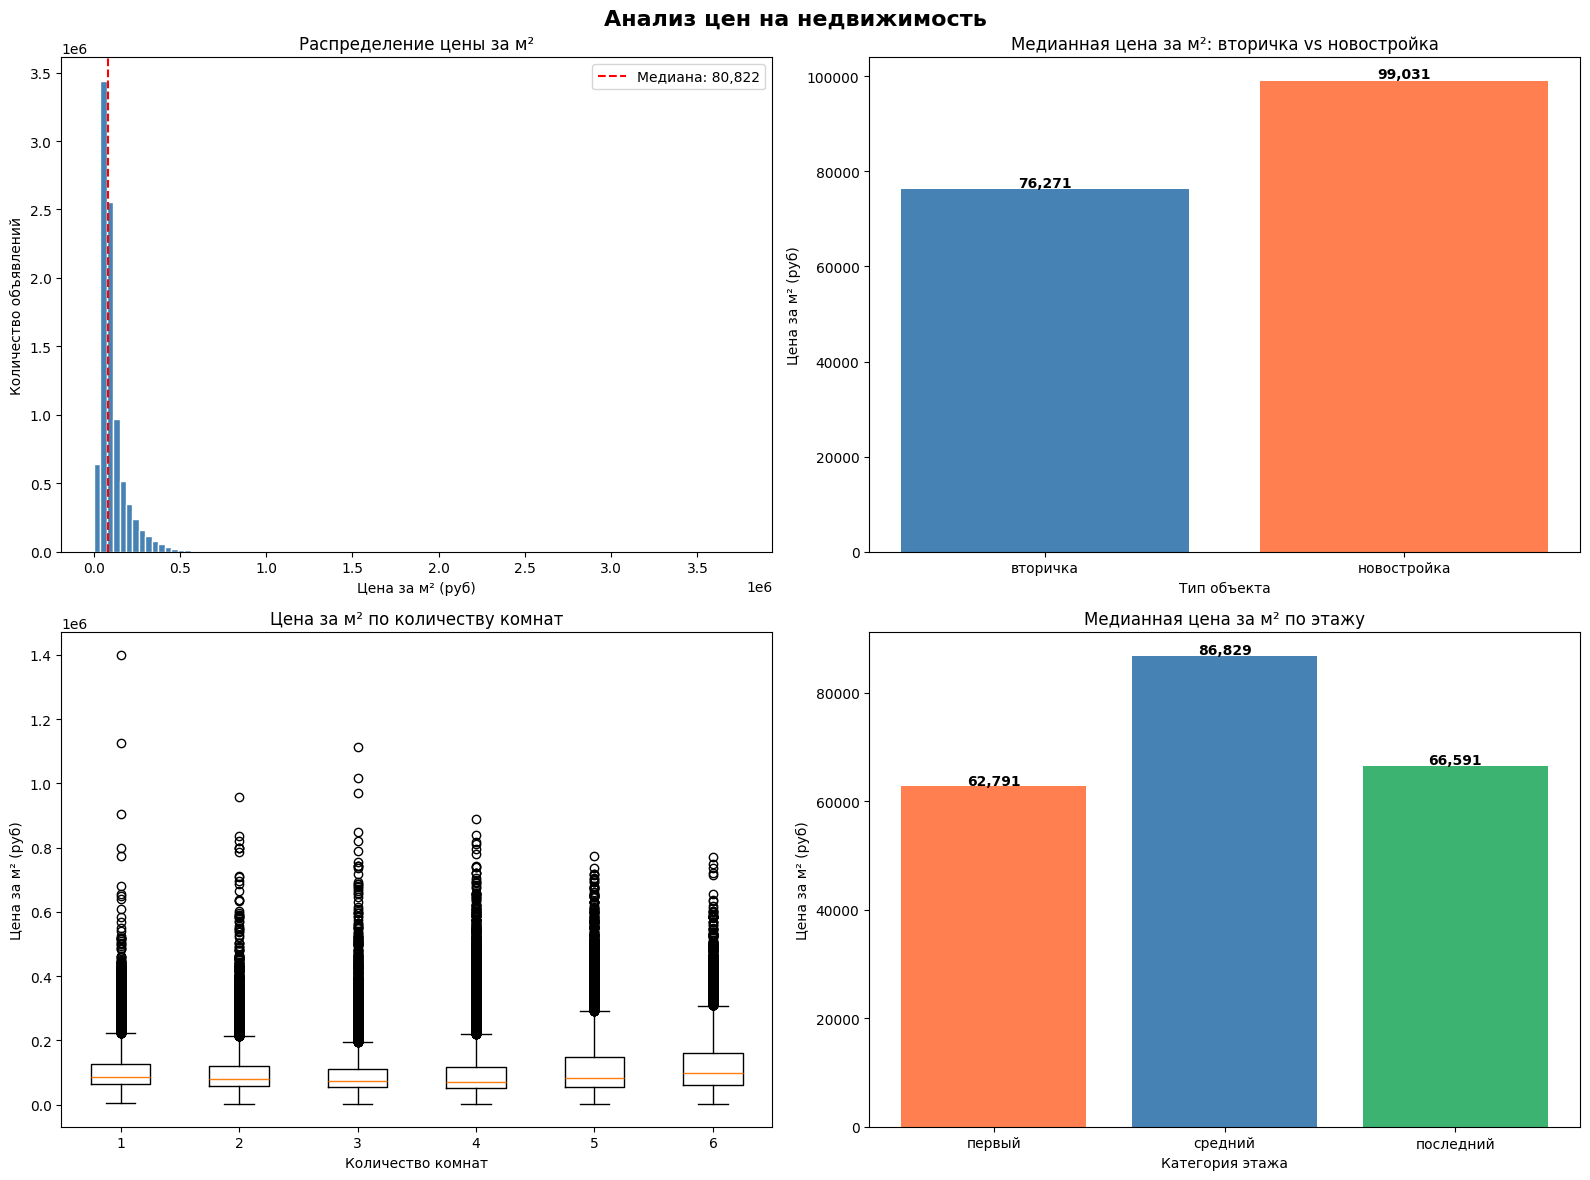

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ цен на недвижимость', fontsize=16, fontweight='bold')


axes[0, 0].hist(df['price_per_m2'], bins=100, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Распределение цены за м²')
axes[0, 0].set_xlabel('Цена за м² (руб)')
axes[0, 0].set_ylabel('Количество объявлений')
axes[0, 0].axvline(df['price_per_m2'].median(), color='red', linestyle='--', label=f"Медиана: {df['price_per_m2'].median():,.0f}")
axes[0, 0].legend()


median_by_type = df.groupby('object_type_name')['price_per_m2'].median()
axes[0, 1].bar(median_by_type.index, median_by_type.values, color=['steelblue', 'coral'])
axes[0, 1].set_title('Медианная цена за м²: вторичка vs новостройка')
axes[0, 1].set_xlabel('Тип объекта')
axes[0, 1].set_ylabel('Цена за м² (руб)')
for i, v in enumerate(median_by_type.values):
    axes[0, 1].text(i, v + 500, f'{v:,.0f}', ha='center', fontweight='bold')


rooms_data = [df[df['rooms'] == r]['price_per_m2'].sample(min(10000, len(df[df['rooms'] == r]))) 
              for r in sorted(df['rooms'].unique()) if r <= 6]
axes[1, 0].boxplot(rooms_data, tick_labels=[str(r) for r in sorted(df['rooms'].unique()) if r <= 6])
axes[1, 0].set_title('Цена за м² по количеству комнат')
axes[1, 0].set_xlabel('Количество комнат')
axes[1, 0].set_ylabel('Цена за м² (руб)')


median_by_floor = df.groupby('floor_category')['price_per_m2'].median().reindex(['первый', 'средний', 'последний'])
axes[1, 1].bar(median_by_floor.index, median_by_floor.values, color=['coral', 'steelblue', 'mediumseagreen'])
axes[1, 1].set_title('Медианная цена за м² по этажу')
axes[1, 1].set_xlabel('Категория этажа')
axes[1, 1].set_ylabel('Цена за м² (руб)')
for i, v in enumerate(median_by_floor.values):
    axes[1, 1].text(i, v + 300, f'{v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Динамика рынка
Анализируем как менялись цены и активность рынка в течение 2021 года.

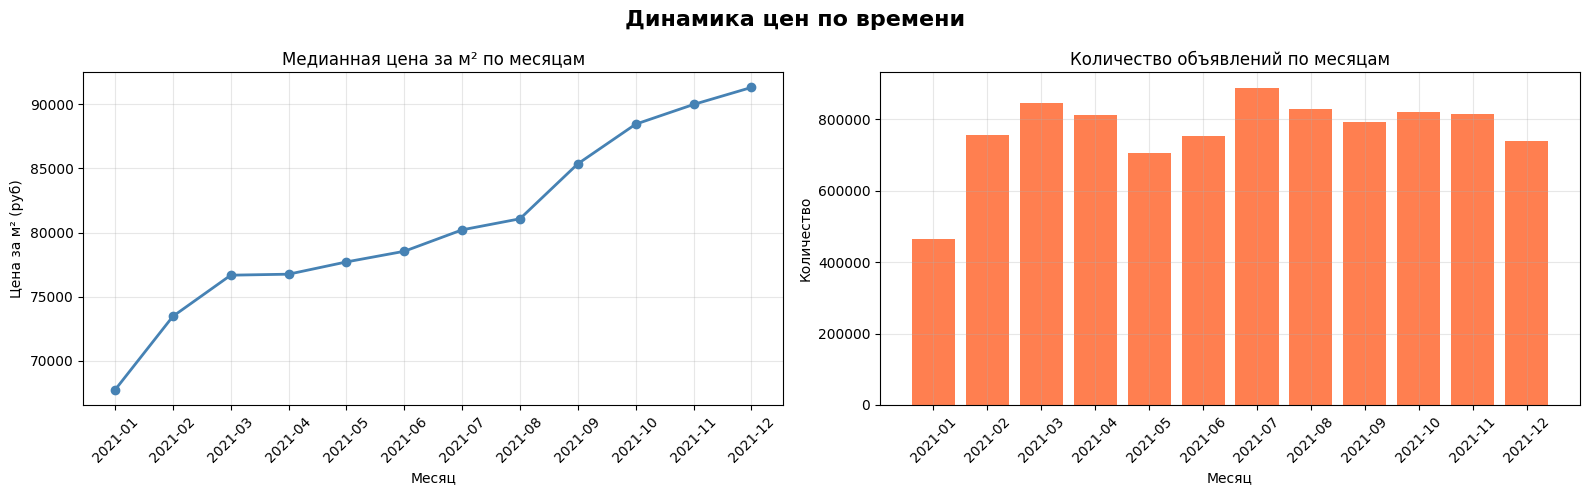

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Динамика цен по времени', fontsize=16, fontweight='bold')

# Медианная цена за м² по месяцам
monthly = df.groupby('month')['price_per_m2'].median()

axes[0].plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=2, marker='o')
axes[0].set_title('Медианная цена за м² по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Цена за м² (руб)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Количество объявлений по месяцам
monthly_count = df.groupby('month')['price'].count()

axes[1].bar(monthly_count.index.astype(str), monthly_count.values, color='coral')
axes[1].set_title('Количество объявлений по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Взаимосвязи признаков
Проверяем корреляции между числовыми признаками.

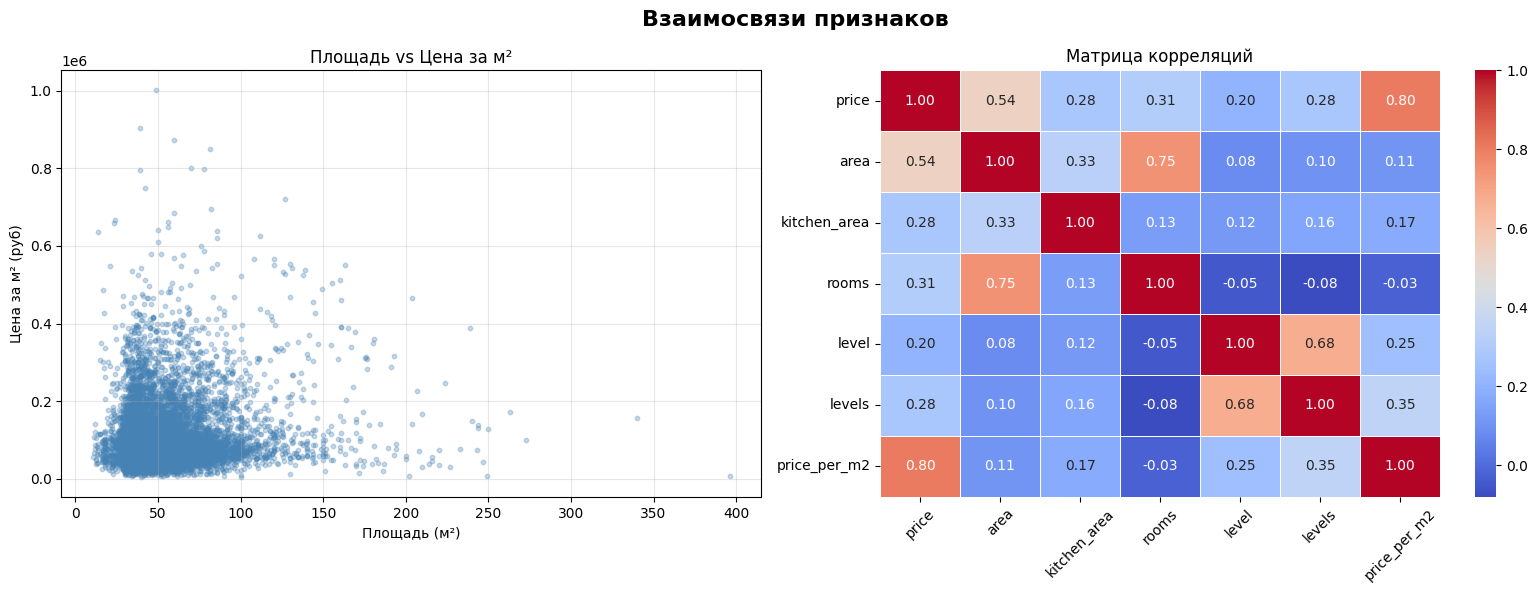

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Взаимосвязи признаков', fontsize=16, fontweight='bold')

# 1. Scatter: площадь vs цена за м²
sample = df.sample(10000, random_state=42)
axes[0].scatter(sample['area'], sample['price_per_m2'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Площадь vs Цена за м²')
axes[0].set_xlabel('Площадь (м²)')
axes[0].set_ylabel('Цена за м² (руб)')
axes[0].grid(True, alpha=0.3)

# 2. Тепловая карта корреляций
corr_cols = ['price', 'area', 'kitchen_area', 'rooms', 'level', 'levels', 'price_per_m2']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Матрица корреляций')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7.Выводы по проекту

### Датасет
- 11.3 млн объявлений по России за 2021 год
- После чистки осталось 9.2 млн строк (убрали дубликаты, аномалии, отрицательные значения)

### Ключевые инсайты

**1. Рынок активно рос весь 2021 год**
Медианная цена за м² выросла с 68,000 до 91,000 руб (+34% за год).
Резкий скачок в январе-марте — вероятно отложенный спрос после пандемии.

**2. Новостройки дороже вторички на 30%**
Медианная цена за м²: новостройки — 99,031 руб, вторичка — 76,271 руб.
Гипотеза подтверждена.

**3. Первый этаж — самый дешёвый**
Медианная цена за м²: первый этаж — 62,791 руб, средние этажи — 86,829 руб.
Дисконт первого этажа составляет ~28% относительно средних этажей.
Гипотеза подтверждена.

**4. Площадь слабо влияет на цену за м²**
Корреляция площади и price_per_m2 = 0.11 — почти нет связи.
Гипотеза о том, что большие квартиры дороже за м² — не подтверждена.

**5. Количество объявлений стабильно**
Рынок активен весь год без сезонных провалов (~750-850k объявлений в месяц).